# 02 — FedAvg baseline + per-round per-attack logging (slow + fast)

What this notebook does:
1. Load the preprocessed data and standardise the features.
2. Stratified 80/20 train/test split (preserving the `source` column).
3. Repartition the training set into four non-IID clients.
4. Define a small MLP classifier.
5. Run sequential-task continual federated learning (FOT-style CFL): four phases of ~7 rounds each, with the active task cycling DoS → Fuzzy → RPM → gear.
6. At each round, evaluate (a) the **global** model — slow memory — and (b) every client's **local** model after its local update — fast memory — per attack type.
7. Save `round_log.csv` (slow) and `fast_log.csv` (fast). These two files are the input for 03.
8. Plot a preview of the per-attack recall curves.

> Kernel: **Python (axi)**

In [1]:
# imports + config
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

DATA_DIR = Path('/Users/lucia/Dropbox/USYD/Semester1_2026/AXI/data/processed')
OUT_DIR  = Path('/Users/lucia/Dropbox/USYD/Semester1_2026/AXI/data/processed')
FIG_DIR  = Path('/Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_CLIENTS    = 4
N_ROUNDS     = 30
LOCAL_EPOCHS = 1
BATCH_SIZE   = 256
LR           = 1e-3
HIDDEN_DIM   = 64
RANDOM_SEED  = 42
ATTACK_TYPES = ['DoS','Fuzzy','RPM','gear']

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {DEVICE}')
print(f'rounds={N_ROUNDS}, clients={N_CLIENTS}, local_epochs={LOCAL_EPOCHS}, batch={BATCH_SIZE}, lr={LR}')

device: mps
rounds=30, clients=4, local_epochs=1, batch=256, lr=0.001


## 1. Load data, standardise features, stratified train/test split

In [2]:
df = pd.read_csv(DATA_DIR / 'can_combined.csv')
feat_cols = ['can_id','dlc'] + [f'b{i}' for i in range(8)]
print(f'full shape: {df.shape}, {len(feat_cols)} features')

# stratified 80/20 train/test (every source — incl. all four attacks — appears in the test set)
train_df, test_df = train_test_split(
    df, test_size=0.20, random_state=RANDOM_SEED, stratify=df['source']
)
print(f'train: {train_df.shape}  test: {test_df.shape}')

# standardise: fit on train, transform both
scaler = StandardScaler().fit(train_df[feat_cols].values)
X_train = scaler.transform(train_df[feat_cols].values).astype(np.float32)
y_train = train_df['label'].values.astype(np.float32)
X_test  = scaler.transform(test_df[feat_cols].values).astype(np.float32)
y_test  = test_df['label'].values.astype(np.float32)
src_test = test_df['source'].values   # used later for per-source evaluation

print(f'X_train: {X_train.shape}, y_train mean (attack ratio): {y_train.mean():.3f}')
print(f'X_test:  {X_test.shape},  y_test  mean: {y_test.mean():.3f}')

full shape: (250000, 13), 10 features
train: (200000, 13)  test: (50000, 13)
X_train: (200000, 10), y_train mean (attack ratio): 0.114
X_test:  (50000, 10),  y_test  mean: 0.113


## 2. Repartition the training set into four non-IID clients (same pattern as 01)

In [3]:
# Each client gets one attack type heavily, plus 10% of the other attacks
src_train = train_df['source'].values
normal_idx_pool = np.where(src_train == 'Normal')[0]
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(normal_idx_pool)
normal_chunks = np.array_split(normal_idx_pool, N_CLIENTS)

clients_X, clients_y, clients_src = [], [], []
for i, atk in enumerate(ATTACK_TYPES):
    own_idx       = np.where(src_train == atk)[0]
    other_mask    = np.isin(src_train, [a for a in ATTACK_TYPES if a != atk])
    other_idx_all = np.where(other_mask)[0]
    n_other       = int(len(other_idx_all) * 0.10)
    other_idx     = rng.choice(other_idx_all, size=n_other, replace=False)

    idx = np.concatenate([normal_chunks[i], own_idx, other_idx])
    rng.shuffle(idx)
    clients_X.append(X_train[idx])
    clients_y.append(y_train[idx])
    clients_src.append(src_train[idx])   # keep the per-row source for the phase filter below
    print(f'  client_{i}_{atk:5s}: {len(idx):>6,} rows  label1={clients_y[-1].mean():.3f}')

  client_0_DoS  : 62,000 rows  label1=0.129


  client_1_Fuzzy: 62,000 rows  label1=0.114
  client_2_RPM  : 62,000 rows  label1=0.119
  client_3_gear : 62,000 rows  label1=0.116


## 3. Model and FL utilities

A small MLP: 10 → 64 → 32 → 1 (logit; BCE loss).

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim=10, hidden=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden//2), nn.ReLU(),
            nn.Linear(hidden//2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def make_loader(X, y, batch=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

def train_local(model, X, y, epochs=LOCAL_EPOCHS, lr=LR):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = make_loader(X, y)
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}

def average_weights(state_dicts, weights=None):
    if weights is None:
        weights = [1.0 / len(state_dicts)] * len(state_dicts)
    avg = copy.deepcopy(state_dicts[0])
    for k in avg.keys():
        avg[k] = sum(w * sd[k] for w, sd in zip(weights, state_dicts))
    return avg

@torch.no_grad()
def predict(model, X, batch=1024):
    model.eval()
    preds = []
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(X[i:i+batch]).to(DEVICE)
        logits = model(xb)
        preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy().astype(int))
    return np.concatenate(preds)

def eval_per_source(model, X_test, y_test, src_test):
    '''Per-source recall (fraction of true-attack rows correctly flagged) plus overall accuracy.'''
    yhat = predict(model, X_test)
    out = {}
    out['overall_acc'] = float((yhat == y_test).mean())
    out['overall_attack_recall'] = float(((yhat == 1) & (y_test == 1)).sum() / max((y_test == 1).sum(), 1))
    for atk in ATTACK_TYPES:
        mask = (src_test == atk) & (y_test == 1)   # attack rows of this source only
        if mask.sum() == 0:
            out[f'recall_{atk}'] = float('nan')
        else:
            out[f'recall_{atk}'] = float(yhat[mask].mean())
    return out

# Initial (untrained) global model + a baseline evaluation
global_model = MLP().to(DEVICE)
init_eval = eval_per_source(global_model, X_test, y_test, src_test)
print('round 0 (untrained):', {k: round(v, 3) for k, v in init_eval.items()})

round 0 (untrained): {'overall_acc': 0.432, 'overall_attack_recall': 0.663, 'recall_DoS': 0.0, 'recall_Fuzzy': 0.751, 'recall_RPM': 1.0, 'recall_gear': 1.0}


## 4. Sequential-task CFL loop with FedAvg, plus per-round fast/slow logging

In [5]:
# Sequential task arrival (FOT-style CFL): attack types appear as sequential phases.
ROUNDS_PER_PHASE = N_ROUNDS // len(ATTACK_TYPES)   # 30 / 4 = 7 (last phase absorbs the remainder)
print(f'CFL phases ({ROUNDS_PER_PHASE} rounds each): ', end='')
print(' -> '.join(ATTACK_TYPES), '\n')

log_rows = []
log_rows.append({'round': 0, 'phase': -1, 'active_task': 'init', **init_eval})
fast_log_rows = []   # fast memory: per-client per-round per-attack recall, BEFORE aggregation

for r in range(1, N_ROUNDS + 1):
    phase       = min((r-1) // ROUNDS_PER_PHASE, len(ATTACK_TYPES)-1)
    active_task = ATTACK_TYPES[phase]

    local_states, weights = [], []
    for i in range(N_CLIENTS):
        # In the current phase, each client only trains on (Normal + active_task) rows.
        mask = (clients_src[i] == 'Normal') | (clients_src[i] == active_task)
        Xi, yi = clients_X[i][mask], clients_y[i][mask]
        if len(Xi) == 0:
            continue
        local_model = MLP().to(DEVICE)
        local_model.load_state_dict(global_model.state_dict())
        sd = train_local(local_model, Xi, yi)   # local_model is the trained state

        # Fast memory: evaluate the just-trained local model on the per-source test sets.
        fast_ev = eval_per_source(local_model, X_test, y_test, src_test)
        for atk in ATTACK_TYPES:
            fast_log_rows.append({
                'round': r, 'phase': phase, 'active_task': active_task,
                'client_id': i, 'client_main': ATTACK_TYPES[i],
                'attack': atk, 'fast_recall': fast_ev[f'recall_{atk}']
            })

        local_states.append(sd)
        weights.append(len(Xi))

    total = sum(weights); weights = [w/total for w in weights]
    global_model.load_state_dict(average_weights(local_states, weights))

    ev = eval_per_source(global_model, X_test, y_test, src_test)
    log_rows.append({'round': r, 'phase': phase, 'active_task': active_task, **ev})
    if r == 1 or r % ROUNDS_PER_PHASE == 0 or r == N_ROUNDS:
        print(f'r{r:>2} [phase={phase} {active_task:5s}] slow: acc={ev["overall_acc"]:.3f}  ' +
              '  '.join([f'{a}={ev[f"recall_{a}"]:.3f}' for a in ATTACK_TYPES]))

log_df  = pd.DataFrame(log_rows)
fast_df = pd.DataFrame(fast_log_rows)
print(f'\nslow log: {log_df.shape}   fast log: {fast_df.shape}')
fast_df.head()

CFL phases (7 rounds each): DoS -> Fuzzy -> RPM -> gear 



r 1 [phase=0 DoS  ] slow: acc=0.887  DoS=0.000  Fuzzy=0.000  RPM=0.000  gear=0.000


r 7 [phase=0 DoS  ] slow: acc=0.918  DoS=1.000  Fuzzy=0.000  RPM=0.000  gear=0.000


r14 [phase=1 Fuzzy] slow: acc=0.911  DoS=0.000  Fuzzy=0.959  RPM=0.000  gear=0.000


r21 [phase=2 RPM  ] slow: acc=0.921  DoS=0.000  Fuzzy=0.241  RPM=1.000  gear=0.000


r28 [phase=3 gear ] slow: acc=0.942  DoS=0.000  Fuzzy=0.016  RPM=1.000  gear=1.000


r30 [phase=3 gear ] slow: acc=0.914  DoS=0.000  Fuzzy=0.009  RPM=0.000  gear=1.000

slow log: (31, 9)   fast log: (480, 7)


,round,phase,active_task,client_id,client_main,attack,fast_recall
0,1,0,DoS,0,DoS,DoS,1.0
1,1,0,DoS,0,DoS,Fuzzy,0.0
2,1,0,DoS,0,DoS,RPM,0.0
3,1,0,DoS,0,DoS,gear,0.0
4,1,0,DoS,1,Fuzzy,DoS,0.0


## 5. Save the round logs (input for notebook 03)

In [6]:
out_path = OUT_DIR / 'round_log.csv'
log_df.to_csv(out_path, index=False)
print(f'saved (slow = global per round):   {out_path}  ({out_path.stat().st_size/1e3:.1f} KB)')

fast_path = OUT_DIR / 'fast_log.csv'
fast_df.to_csv(fast_path, index=False)
print(f'saved (fast = local per round/client/attack): {fast_path}  ({fast_path.stat().st_size/1e3:.1f} KB)')

saved (slow = global per round):   /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/data/processed/round_log.csv  (2.1 KB)
saved (fast = local per round/client/attack): /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/data/processed/fast_log.csv  (13.4 KB)


## 6. Preview: per-attack recall over sequential-task CFL rounds (preview of Figure A)

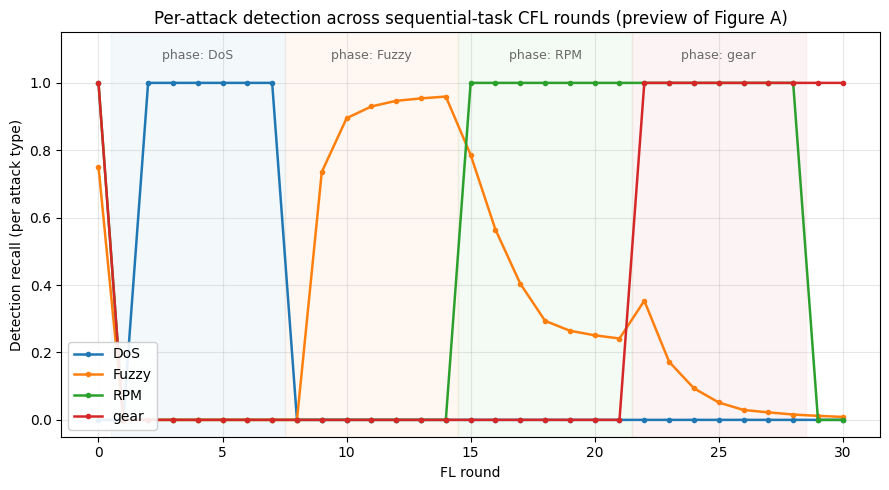

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/preview_per_attack_recall.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ROUNDS_PER_PHASE = N_ROUNDS // len(ATTACK_TYPES)
for atk in ATTACK_TYPES:
    ax.plot(log_df['round'], log_df[f'recall_{atk}'], marker='o', markersize=3, label=atk, linewidth=1.8)
# phase shading and labels
for i, atk in enumerate(ATTACK_TYPES):
    ax.axvspan(i*ROUNDS_PER_PHASE+0.5, (i+1)*ROUNDS_PER_PHASE+0.5, alpha=0.05, color=['C0','C1','C2','C3'][i])
    ax.text((i+0.5)*ROUNDS_PER_PHASE+0.5, 1.07, f'phase: {atk}', ha='center', fontsize=9, color='dimgray')
ax.set_xlabel('FL round')
ax.set_ylabel('Detection recall (per attack type)')
ax.set_title('Per-attack detection across sequential-task CFL rounds (preview of Figure A)')
ax.legend(loc='lower left', framealpha=0.9); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
fig_path = FIG_DIR / 'preview_per_attack_recall.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'saved: {fig_path}')

## 7. Summary

In [8]:
last = log_df.iloc[-1]
print('='*60); print('FedAvg baseline summary (slow + fast)'); print('='*60)
print(f'final round ({int(last["round"])}):')
print(f'  overall accuracy: {last["overall_acc"]:.3f}')
print(f'  overall attack recall: {last["overall_attack_recall"]:.3f}')

print('\nper-attack slow (global) recall:')
for atk in ATTACK_TYPES:
    first = log_df[f'recall_{atk}'].iloc[1]
    best  = log_df[f'recall_{atk}'].max()
    final = last[f'recall_{atk}']
    print(f'  {atk:5s}: first={first:.3f}  best={best:.3f}  final={final:.3f}  forgetting={best-final:+.3f}')

print('\nFast vs slow consolidation gap (NL signal) — at the final round:')
last_r = int(last["round"])
fast_last = fast_df[fast_df["round"]==last_r]
for atk in ATTACK_TYPES:
    fast_vals = fast_last[fast_last["attack"]==atk]["fast_recall"].values
    slow_val  = last[f"recall_{atk}"]
    print(f'  {atk:5s}: slow={slow_val:.3f}  fast(client avg)={fast_vals.mean():.3f}  gap(fast-slow)={fast_vals.mean()-slow_val:+.3f}')

print('\nfiles saved:')
print(f'  data/processed/round_log.csv  (slow = global per round)')
print(f'  data/processed/fast_log.csv   (fast = local per round/client/attack)')
print(f'  figures/preview_per_attack_recall.png')
print('\nNext: 03_nl_explanation builds Figure A and the consolidation-gap analysis from these two logs.')

FedAvg baseline summary (slow + fast)
final round (30):
  overall accuracy: 0.914
  overall attack recall: 0.246

per-attack slow (global) recall:
  DoS  : first=0.000  best=1.000  final=0.000  forgetting=+1.000
  Fuzzy: first=0.000  best=0.959  final=0.009  forgetting=+0.951
  RPM  : first=0.000  best=1.000  final=0.000  forgetting=+1.000
  gear : first=0.000  best=1.000  final=1.000  forgetting=+0.000

Fast vs slow consolidation gap (NL signal) — at the final round:
  DoS  : slow=0.000  fast(client avg)=0.000  gap(fast-slow)=+0.000
  Fuzzy: slow=0.009  fast(client avg)=0.010  gap(fast-slow)=+0.001
  RPM  : slow=0.000  fast(client avg)=0.000  gap(fast-slow)=+0.000
  gear : slow=1.000  fast(client avg)=1.000  gap(fast-slow)=+0.000

files saved:
  data/processed/round_log.csv  (slow = global per round)
  data/processed/fast_log.csv   (fast = local per round/client/attack)
  figures/preview_per_attack_recall.png

Next: 03_nl_explanation builds Figure A and the consolidation-gap analysis 